# 🚢 Titanic Survival Analysis using Matplotlib

## 📖 Project Overview

The Titanic disaster is one of the most well-known historical events and is widely used for learning data analysis and visualization.

In this project, we will analyze the Titanic dataset using **Matplotlib** to explore passenger demographics, survival patterns, ticket classes, fares, and other important factors.

The goal is to demonstrate how Matplotlib can be used for real-world exploratory data analysis (EDA).

---

## 🎯 Objectives

In this notebook, we will:

- Load and explore the Titanic dataset.
- Perform basic data cleaning.
- Analyze passenger demographics.
- Visualize survival patterns.
- Explore relationships between different features.
- Draw meaningful insights using Matplotlib.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
df = pd.read_csv(r"C:\Users\Anupa\Desktop\Python-Data-Visualization\Python-Data-Visualization\Datasets\titanic.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 📊 Dataset Overview

Before creating visualizations, it's important to understand the structure of the dataset.

We'll examine:

- Dataset dimensions (rows and columns)
- Data types of each feature
- Missing values and data quality
- Statistical summary of numerical features
- Distribution of categorical variables

In [7]:
df.shape

(891, 15)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [9]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
df.describe(include=["object", "string"])

,sex,embarked,class,who,deck,embark_town,alive
count,891,891,891,891,891,891,891
unique,2,3,3,3,8,3,2
top,male,S,Third,man,Unknown,Southampton,no
freq,577,646,491,537,688,646,549


In [11]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# 🧹 Data Cleaning

Real-world datasets often contain missing values.

Before visualization, we'll inspect and handle these missing values to ensure accurate analysis.

In [12]:
missing = df.isnull().sum()

missing

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [13]:
df["age"] = df["age"].fillna(df["age"].median())

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

df["deck"] = df["deck"].fillna("Unknown")

In [14]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

# 📈 Univariate Analysis

This analysis helps us understand the distribution of individual variables without considering relationships with other variables.

This visualization helps us analyze:

- Passenger age distribution
- Passenger class distribution
- Gender distribution
- Survival distribution
- Overall characteristics of the passengers

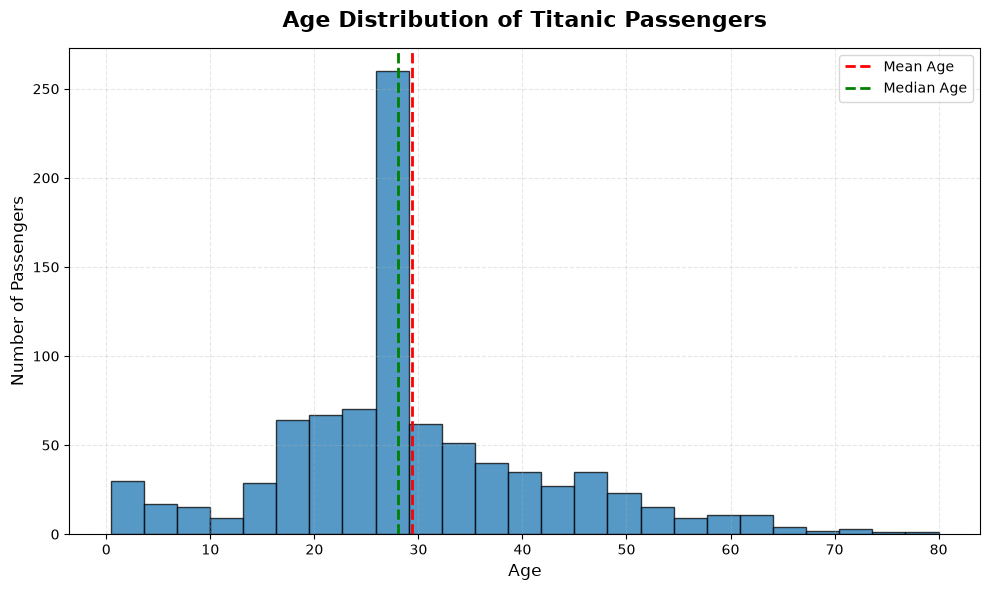

In [38]:
# This histogram shows the distribution of passengers' ages.
# It helps us understand the most common age groups, the spread of ages,
# and whether there are any unusual age patterns or outliers.

plt.figure(figsize=(10,6))

# Create the histogram
plt.hist(
    df["age"],
    bins=25,
    edgecolor="black",
    alpha=0.75
)

# Add a line for the average age
plt.axvline(
    df["age"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Mean Age"
)

# Add a line for the median age
plt.axvline(
    df["age"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label="Median Age"
)

# Add title
plt.title(
    "Age Distribution of Titanic Passengers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Age",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

# Add grid
plt.grid(
    alpha=0.3,
    linestyle="--"
)

# Display legend
plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- Most passengers were between **20 and 35 years** of age, indicating that young adults formed the largest group on the Titanic.
- The **mean age** is slightly higher than the **median age**, suggesting that the age distribution is **slightly right-skewed** due to the presence of older passengers.
- A smaller number of child passengers (below 10 years) and elderly passengers (above 60 years) were present on board.
- The passenger count gradually decreases as age increases, with very few passengers above **70 years** of age.
- Overall, the Titanic passenger population was primarily composed of young and middle-aged adults.

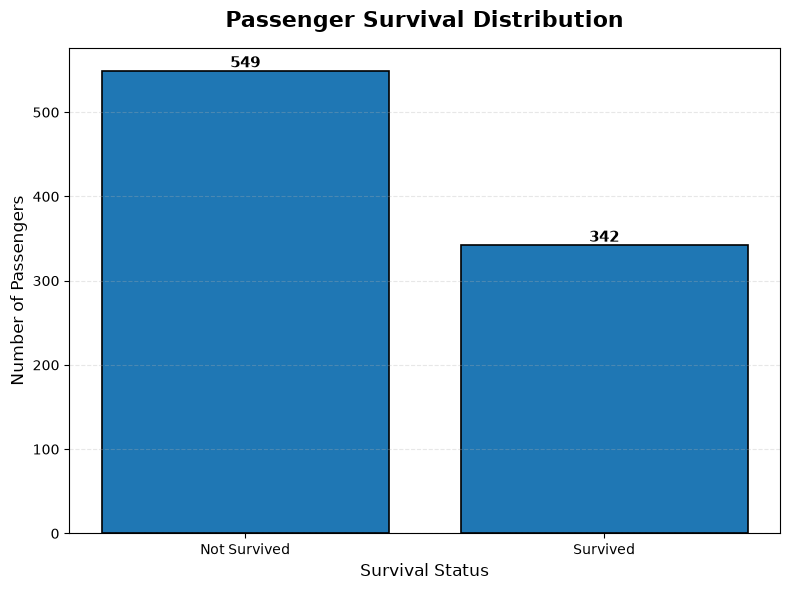

In [39]:
# This bar chart shows the number of passengers who survived
# and those who did not survive the Titanic disaster.
# It helps us understand the overall survival distribution.

# Count survived and non-survived passengers
survival = df["survived"].value_counts().sort_index()

# Create the figure
plt.figure(figsize=(8,6))

# Create the bar chart
bars = plt.bar(
    ["Not Survived", "Survived"],
    survival.values,
    edgecolor="black",
    linewidth=1.2
)

# Add title
plt.title(
    "Passenger Survival Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Survival Status",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

# Add horizontal grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Display value labels on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

### 📌 Observation

- Out of **891 passengers**, **549 passengers (61.6%)** did not survive, while **342 passengers (38.4%)** survived the Titanic disaster.
- The number of **non-survivors** is significantly higher than the number of survivors, indicating that the majority of passengers lost their lives.
- The noticeable difference between the two groups highlights the severity of the disaster and the limited availability of rescue resources.
- The survival distribution suggests that not every passenger had an equal chance of survival, indicating that factors such as **gender, passenger class, age, and fare** may have influenced survival outcomes.
- This analysis provides a strong foundation for exploring the key factors that affected passenger survival in the subsequent sections.

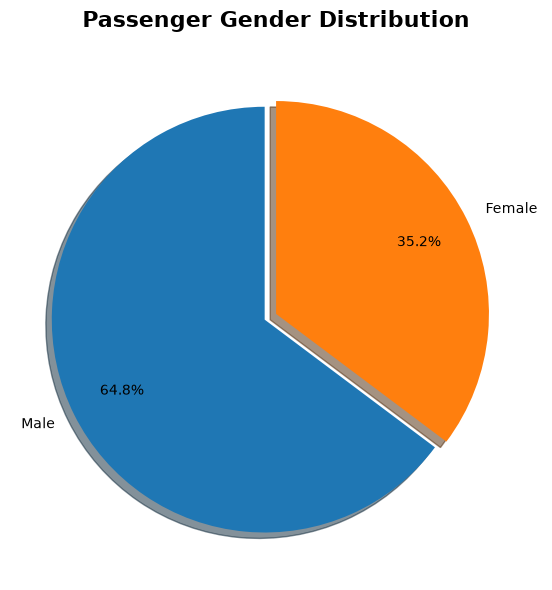

In [40]:
# This pie chart shows the gender distribution of Titanic passengers.
# It helps us understand the proportion of male and female passengers
# who were aboard the Titanic.

# Count male and female passengers
gender = df["sex"].value_counts()

# Create the figure
plt.figure(figsize=(8,6))

# Create the pie chart
plt.pie(
    gender.values,
    labels=gender.index.str.title(),
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.06, 0),
    shadow=True,
    pctdistance=0.75
)

# Add title
plt.title(
    "Passenger Gender Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.show()

### 📌 Observation

- Male passengers accounted for **64.8%** of the total passenger population, making them the majority on the Titanic.
- Female passengers represented **35.2%** of all passengers, indicating that women made up a smaller proportion of the dataset.
- The passenger population was therefore predominantly male, with nearly **two-thirds** of all passengers being men.
- This noticeable gender imbalance suggests that gender-based analyses are important for understanding the overall survival patterns.
- The gender distribution serves as a valuable baseline for comparing survival rates between male and female passengers in the following sections.

# 📊 Bivariate Analysis

Bivariate analysis helps us understand the relationship between two variables and identify important patterns in the dataset.

This visualization helps us analyze:

- Survival by gender
- Survival by passenger class
- Age vs survival
- Fare vs survival
- Relationships that influence passenger survival

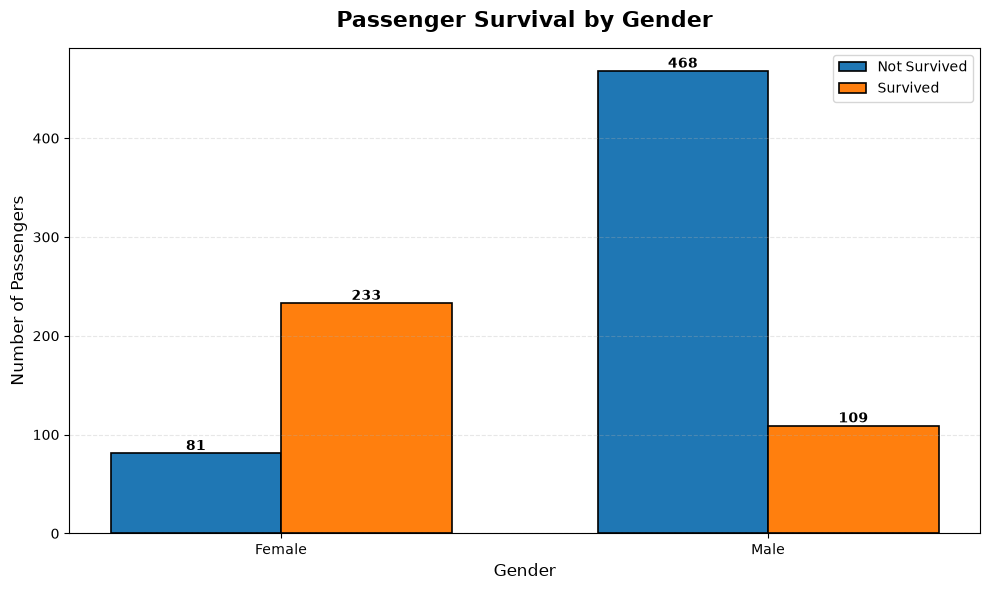

In [41]:
# This grouped bar chart compares survival counts between
# male and female passengers. It helps us understand
# whether gender influenced survival during the Titanic disaster.

# Create a cross-tabulation of gender and survival
gender_survival = pd.crosstab(df["sex"], df["survived"])

# Extract values
gender = gender_survival.index
not_survived = gender_survival[0]
survived = gender_survival[1]

# Set bar positions
x = np.arange(len(gender))
width = 0.35

# Create the figure
plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(
    x - width/2,
    not_survived,
    width,
    label="Not Survived",
    edgecolor="black",
    linewidth=1.2
)

bars2 = plt.bar(
    x + width/2,
    survived,
    width,
    label="Survived",
    edgecolor="black",
    linewidth=1.2
)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{int(bar.get_height())}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Title
plt.title(
    "Passenger Survival by Gender",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Gender",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

# X-axis labels
plt.xticks(
    x,
    ["Female", "Male"]
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- Among **female passengers**, **233 survived** while **81 did not survive**, indicating that the majority of women survived the Titanic disaster.
- In contrast, **468 male passengers did not survive**, whereas only **109 survived**, making males the largest group of non-survivors.
- Female passengers had a significantly higher survival rate compared to male passengers.
- The large difference between male and female survival counts suggests that **gender had a strong influence on survival outcomes**.
- Overall, the analysis indicates that women were considerably more likely to survive than men during the Titanic disaster.

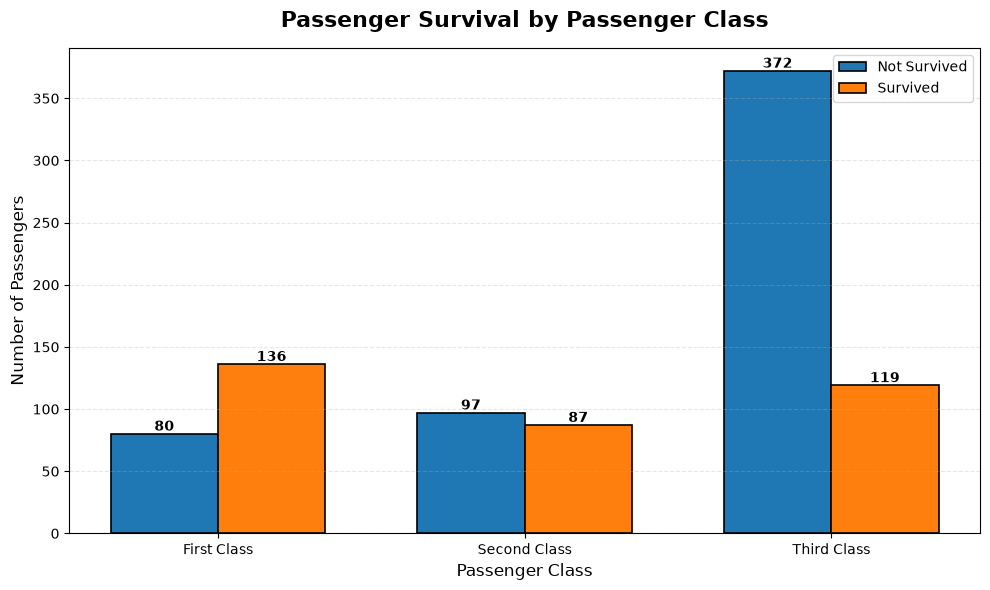

In [42]:
# This grouped bar chart compares survival counts across
# different passenger classes (1st, 2nd, and 3rd Class).
# It helps us understand how passenger class influenced survival.

# Create a cross-tabulation of passenger class and survival
class_survival = pd.crosstab(df["pclass"], df["survived"])

# Extract values
classes = class_survival.index.astype(str)
not_survived = class_survival[0]
survived = class_survival[1]

# Set bar positions
x = np.arange(len(classes))
width = 0.35

# Create the figure
plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(
    x - width/2,
    not_survived,
    width,
    label="Not Survived",
    edgecolor="black",
    linewidth=1.2
)

bars2 = plt.bar(
    x + width/2,
    survived,
    width,
    label="Survived",
    edgecolor="black",
    linewidth=1.2
)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{int(bar.get_height())}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Title
plt.title(
    "Passenger Survival by Passenger Class",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Passenger Class",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

# X-axis labels
plt.xticks(
    x,
    ["First Class", "Second Class", "Third Class"]
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- **First Class** passengers had the highest survival count, with **136 survivors** compared to **80 non-survivors**, indicating the best survival outcome among all passenger classes.
- **Second Class** passengers showed a relatively balanced distribution, with **87 survivors** and **97 non-survivors**, suggesting a moderate chance of survival.
- **Third Class** passengers experienced the largest number of fatalities, with **372 non-survivors** compared to only **119 survivors**.
- The substantial difference in survival counts across passenger classes indicates that passengers in **higher classes were more likely to survive** than those traveling in lower classes.
- Overall, the analysis suggests that **passenger class had a significant impact on survival during the Titanic disaster.**

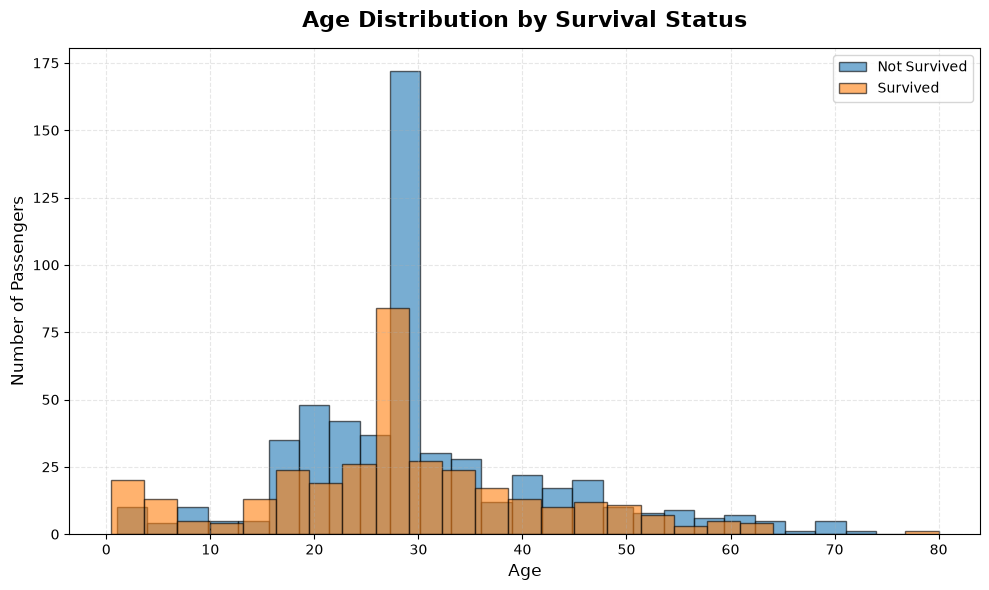

In [43]:
# This histogram compares the age distribution of passengers
# who survived and those who did not survive.
# It helps us understand whether age influenced survival.

# Separate passenger ages based on survival status
survived = df[df["survived"] == 1]["age"]

not_survived = df[df["survived"] == 0]["age"]

# Create the figure
plt.figure(figsize=(10,6))

# Histogram for passengers who did not survive
plt.hist(
    not_survived,
    bins=25,
    alpha=0.6,
    edgecolor="black",
    label="Not Survived"
)

# Histogram for passengers who survived
plt.hist(
    survived,
    bins=25,
    alpha=0.6,
    edgecolor="black",
    label="Survived"
)

# Add title
plt.title(
    "Age Distribution by Survival Status",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Age",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

# Grid
plt.grid(
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- The majority of both **survivors** and **non-survivors** were between **20 and 35 years** of age, as this was the largest passenger age group on the Titanic.
- A relatively higher proportion of **children (below 10 years)** survived compared to older age groups, suggesting that younger passengers had better survival outcomes.
- The number of **non-survivors** is noticeably higher than the number of survivors across most adult age groups, reflecting the overall low survival rate of the disaster.
- Very few passengers were above **60 years** of age, resulting in limited observations for elderly passengers.
- Overall, the analysis suggests that **age influenced survival**, particularly for younger passengers, although other factors such as **gender and passenger class** also played an important role.

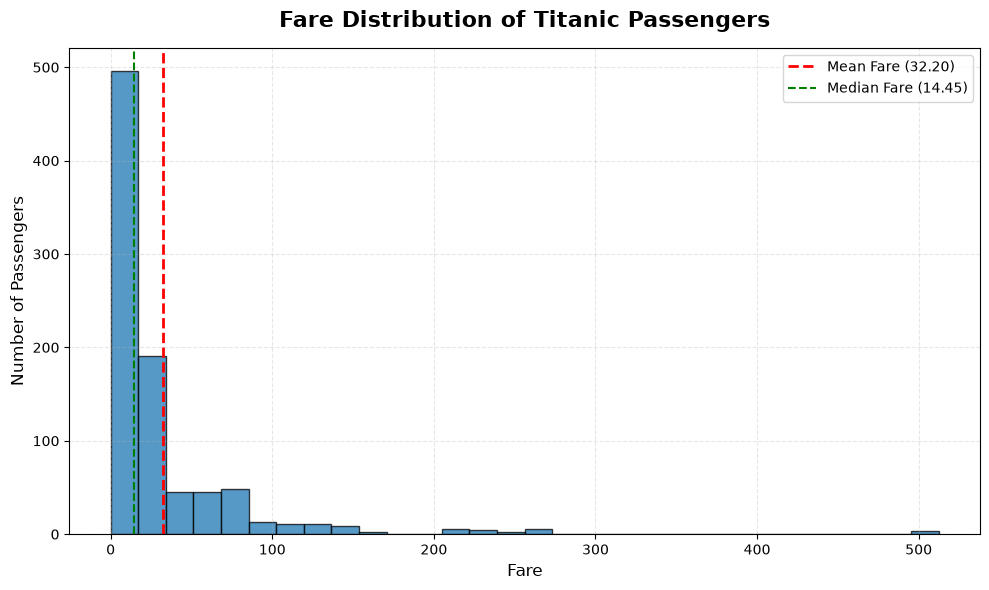

In [45]:
# This histogram shows the distribution of passenger fares.
# It helps us understand the most common ticket prices,
# the spread of fares, and the presence of high-value tickets.

plt.figure(figsize=(10,6))

# Create the histogram
plt.hist(
    df["fare"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

# Add mean fare line
plt.axvline(
    df["fare"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean Fare ({df['fare'].mean():.2f})"
)

# Add median fare line
plt.axvline(
    df["fare"].median(),
    color="green",
    linestyle="--",
    label=f"Median Fare ({df['fare'].median():.2f})"
)

# Title
plt.title(
    "Fare Distribution of Titanic Passengers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Fare",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

# Grid
plt.grid(
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- Most passengers purchased **low-priced tickets**, with the majority of fares concentrated below **50**.
- The fare distribution is **highly right-skewed**, as a small number of passengers paid exceptionally high fares.
- The **mean fare** is noticeably higher than the **median fare**, indicating the presence of a few expensive ticket outliers that increase the average fare.
- Only a limited number of passengers paid premium fares above **100**, while the majority traveled with relatively inexpensive tickets.
- Overall, the wide variation in ticket fares reflects the different passenger classes and socioeconomic backgrounds of those aboard the Titanic.

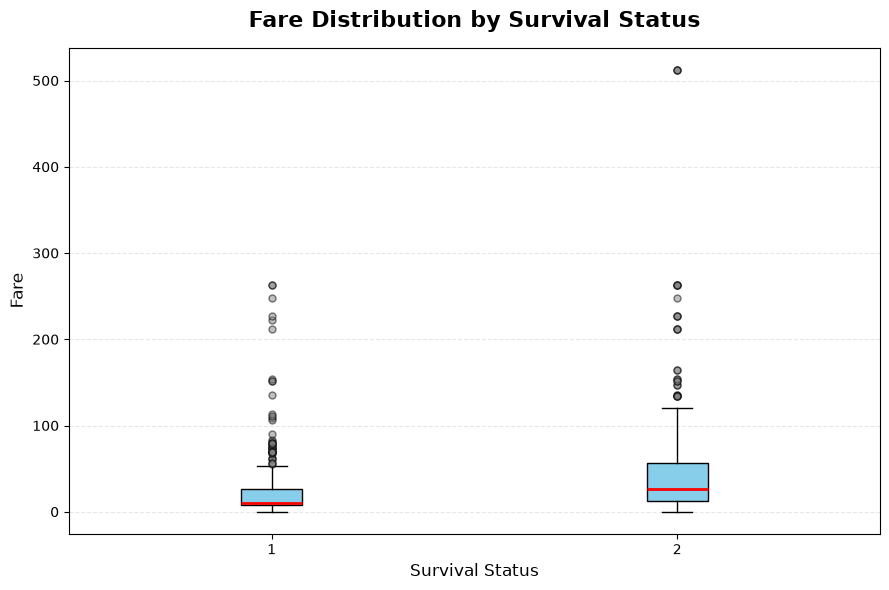

In [48]:
# This box plot compares the fare distribution of passengers
# who survived and those who did not survive.
# It helps identify differences in ticket prices, median fares,
# variability, and outliers between the two groups.

# Separate fares based on survival status
fare_survived = df[df["survived"] == 1]["fare"]

fare_not_survived = df[df["survived"] == 0]["fare"]

# Create the figure
plt.figure(figsize=(9,6))

# Create the box plot
plt.boxplot(
    [fare_not_survived, fare_survived],
    label=["Not Survived", "Survived"],   # not label=
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="black"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(
        marker="o",
        markerfacecolor="gray",
        markersize=5,
        alpha=0.5
    )
)

# Title
plt.title(
    "Fare Distribution by Survival Status",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Survival Status",
    fontsize=12
)

plt.ylabel(
    "Fare",
    fontsize=12
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### 📌 Observation

- Passengers who **survived** generally paid **higher ticket fares** than those who did not survive, as indicated by the higher median fare.
- The **interquartile range (IQR)** for survivors is wider, showing greater variation in ticket fares among surviving passengers.
- Both groups contain several **high-fare outliers**, but survivors include the highest-value fares, with one passenger paying a fare above **500**.
- Most non-survivors purchased relatively **low-priced tickets**, with their fare distribution concentrated in the lower range.
- Overall, the analysis suggests a positive association between **higher ticket fares and survival**, indicating that passengers who paid more for their tickets were more likely to survive.

# 📊 Multivariate Analysis

Multivariate analysis explores relationships among multiple variables simultaneously, providing deeper insights into passenger characteristics and survival patterns.

This visualization helps us analyze:

- Age and fare relationships
- Passenger class and fare
- Embarkation patterns
- Family size distribution
- Combined factors affecting survival

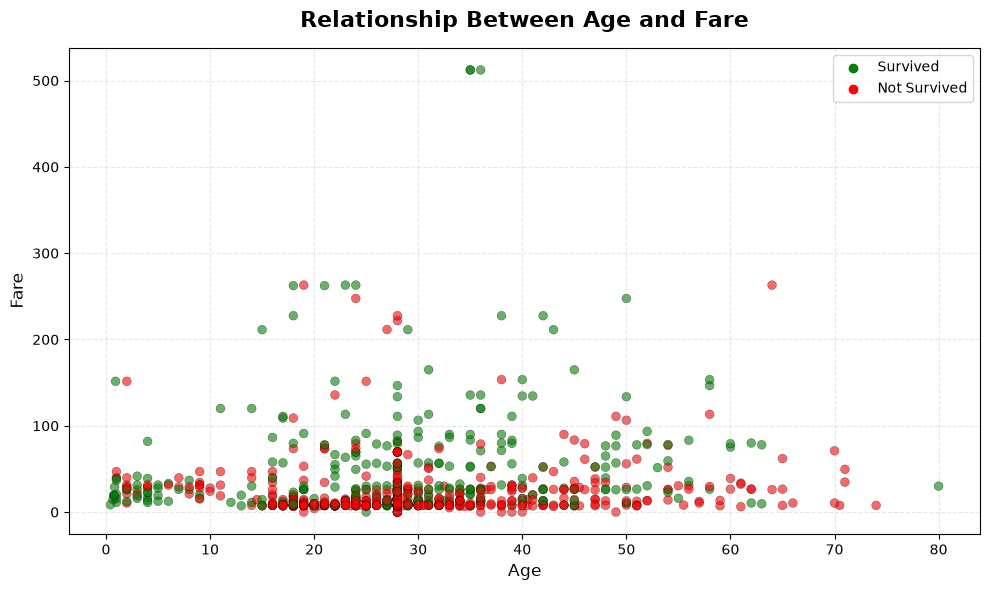

In [49]:
# This scatter plot shows the relationship between passenger age and ticket fare.
# The colors represent survival status, helping us understand how age, fare,
# and survival are related.

plt.figure(figsize=(10,6))

# Assign colors based on survival status
colors = df["survived"].map({
    0: "red",
    1: "green"
})

# Create scatter plot
plt.scatter(
    df["age"],
    df["fare"],
    c=colors,
    s=40,
    alpha=0.6,
    edgecolors="black",
    linewidths=0.3
)

# Create custom legend
plt.scatter([], [], color="green", label="Survived")
plt.scatter([], [], color="red", label="Not Survived")

# Title
plt.title(
    "Relationship Between Age and Fare",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Age",
    fontsize=12
)

plt.ylabel(
    "Fare",
    fontsize=12
)

# Grid
plt.grid(
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- Most passengers were between **20 and 40 years** of age and paid **lower ticket fares**, creating a dense cluster in the lower-left region of the plot.
- A large number of **survivors (green points)** are associated with **higher ticket fares**, suggesting that passengers who paid more had better survival outcomes.
- **Non-survivors (red points)** are predominantly concentrated in the **low-fare range**, indicating that passengers with lower-priced tickets were less likely to survive.
- There is **no clear linear relationship between age and fare**, as passengers of different ages paid a wide range of ticket prices.
- Several high-fare outliers are visible, and most of these passengers survived, reinforcing the relationship between **higher fares and increased survival probability**.
- Overall, **ticket fare appears to have a stronger influence on survival than age**, while age alone does not show a distinct pattern.

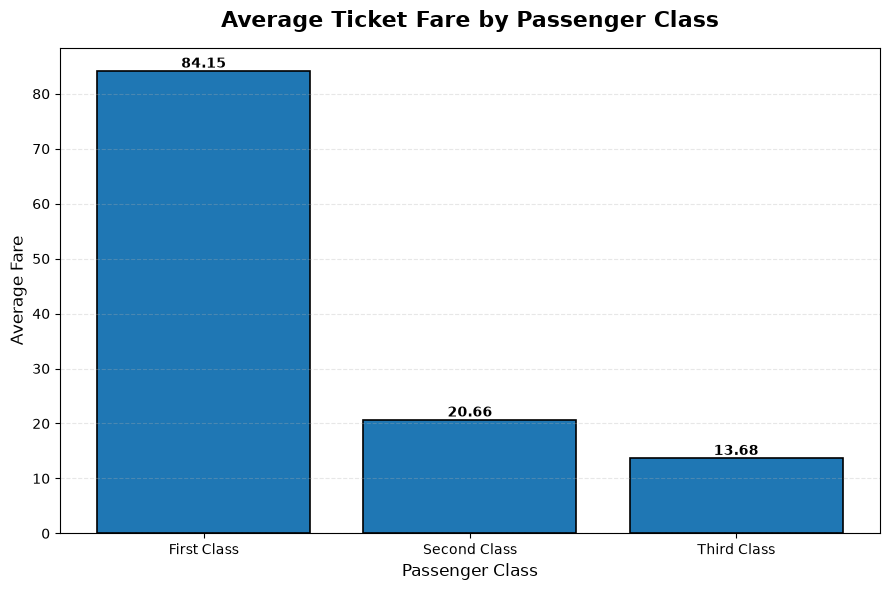

In [50]:
# This bar chart compares the average ticket fare
# across the three passenger classes.
# It helps us understand how ticket prices varied
# based on passenger class.

# Calculate average fare for each passenger class
fare_class = df.groupby("pclass")["fare"].mean()

# Create the figure
plt.figure(figsize=(9,6))

# Create the bar chart
bars = plt.bar(
    ["First Class", "Second Class", "Third Class"],
    fare_class.values,
    edgecolor="black",
    linewidth=1.2
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Title
plt.title(
    "Average Ticket Fare by Passenger Class",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Passenger Class",
    fontsize=12
)

plt.ylabel(
    "Average Fare",
    fontsize=12
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### 📌 Observation

- **First Class** passengers paid the highest average ticket fare, approximately **84.15**, which is significantly higher than the other two classes.
- **Second Class** passengers paid an average fare of approximately **20.66**, representing a moderate ticket price.
- **Third Class** passengers paid the lowest average fare, approximately **13.68**, making it the most affordable travel option.
- The average fare for **First Class** is nearly **four times higher than Second Class** and more than **six times higher than Third Class**, highlighting the substantial economic differences among passenger classes.
- Overall, the analysis demonstrates a clear increase in average ticket fare from **Third Class** to **First Class**, reflecting differences in accommodation quality, onboard services, and passenger socioeconomic status.

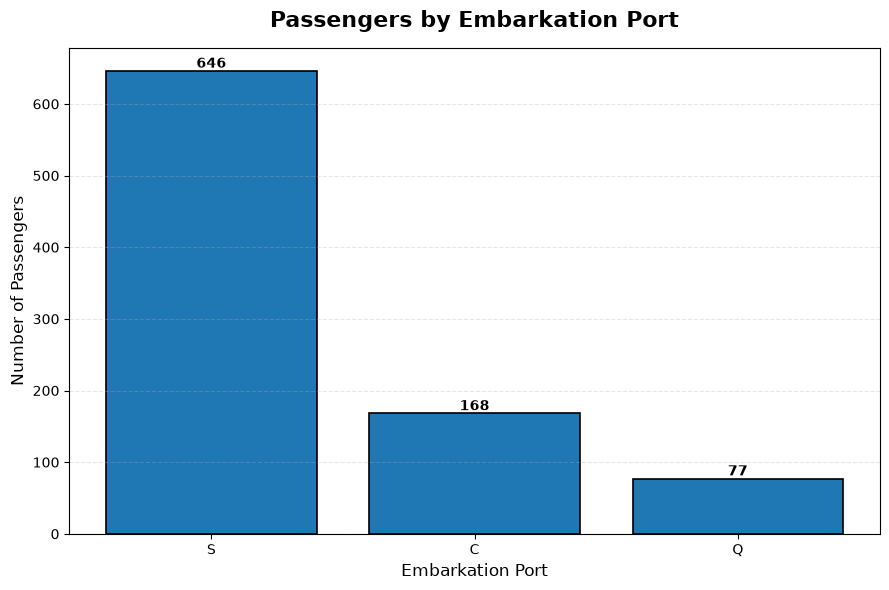

In [51]:
# This bar chart shows the number of passengers
# who boarded the Titanic from each embarkation port.
# It helps us understand the distribution of passengers
# across different boarding locations.

# Count passengers from each embarkation port
embarked = df["embarked"].value_counts()

# Create the figure
plt.figure(figsize=(9,6))

# Create the bar chart
bars = plt.bar(
    embarked.index,
    embarked.values,
    edgecolor="black",
    linewidth=1.2
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Title
plt.title(
    "Passengers by Embarkation Port",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Embarkation Port",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### 📌 Observation

- **Southampton (S)** was the primary embarkation port, with **646 passengers** boarding from this location, making it the busiest departure point.
- **Cherbourg (C)** had **168 passengers**, making it the second most common embarkation port.
- **Queenstown (Q)** had the fewest passengers, with only **77 passengers** boarding from this port.
- The majority of passengers began their journey from **Southampton**, while relatively few boarded from **Cherbourg** and **Queenstown**.
- Overall, the passenger distribution across embarkation ports was highly uneven, with Southampton accounting for the largest share of passengers.

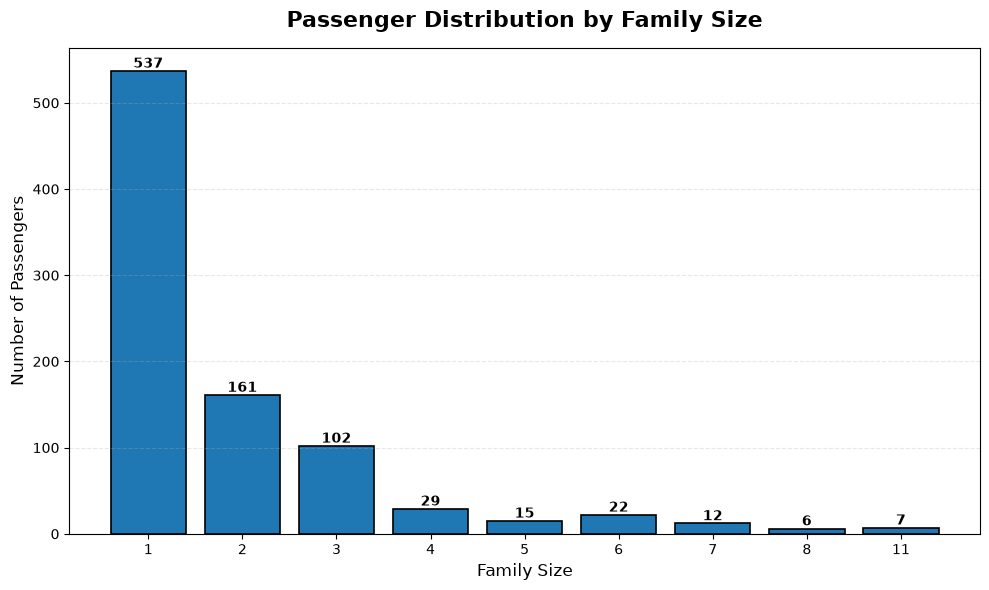

In [54]:
# This bar chart shows the distribution of passengers
# based on their family size aboard the Titanic.
# Family Size = Siblings/Spouses + Parents/Children + Passenger

# Create a new feature for family size
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Count passengers by family size
family = df["family_size"].value_counts().sort_index()

# Create the figure
plt.figure(figsize=(10,6))

# Create the bar chart
bars = plt.bar(
    family.index.astype(str),
    family.values,
    edgecolor="black",
    linewidth=1.2
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Title
plt.title(
    "Passenger Distribution by Family Size",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel(
    "Family Size",
    fontsize=12
)

plt.ylabel(
    "Number of Passengers",
    fontsize=12
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### 📌 Observation

- The majority of passengers (**537 passengers**) traveled **alone**, with a **family size of 1**, making solo travelers the largest group on the Titanic.
- Small family groups were the next most common, with **161 passengers** traveling in families of **2 members** and **102 passengers** in families of **3 members**.
- The number of passengers decreases significantly as **family size increases**, indicating that large family groups were relatively uncommon.
- Only a small number of passengers traveled in families larger than **5 members**, with very few passengers belonging to families of **8 or 11 members**.
- Overall, the passenger distribution suggests that **traveling alone or with a small family was far more common than traveling in large groups**.

# 🔥 Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables. It helps identify which features are positively or negatively associated and provides insights into the overall structure of the dataset.

This visualization helps us analyze:

- Relationships among numerical variables
- Positive and negative correlations
- Strong and weak feature associations
- Variables that may influence survival


In [31]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=["number"])

correlation = numerical_df.corr()

correlation

,survived,pclass,age,sibsp,parch,fare,family_size
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
family_size,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


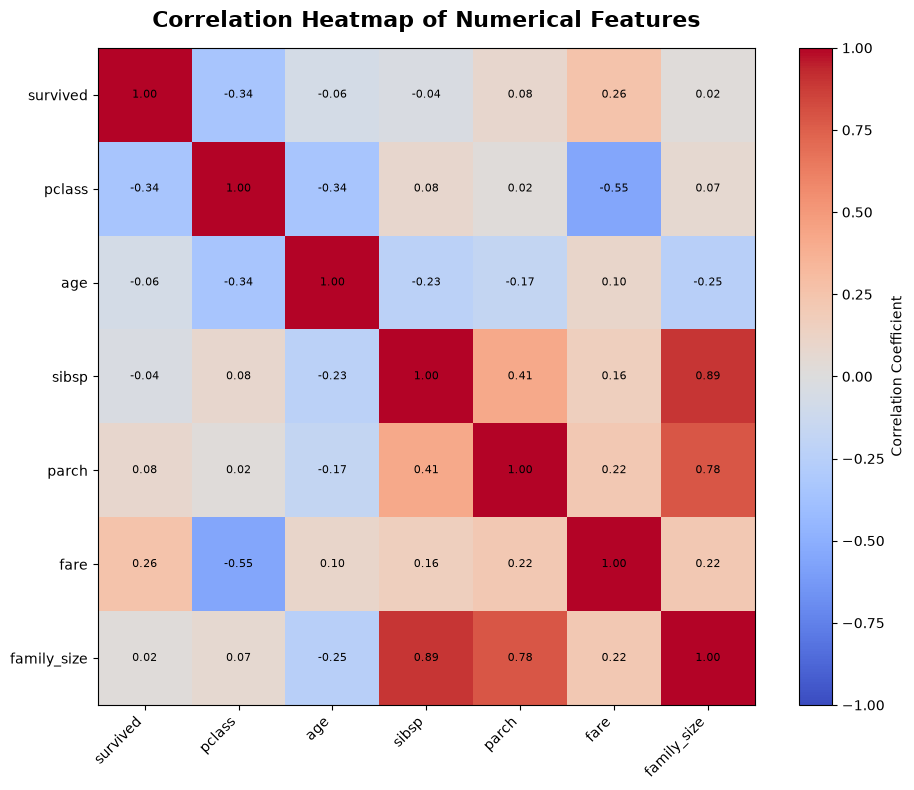

In [55]:
# Create the figure
plt.figure(figsize=(10,8))

# Display heatmap
plt.imshow(
    correlation,
    cmap="coolwarm",
    interpolation="nearest",
    vmin=-1,
    vmax=1
)

# Add color bar
plt.colorbar(label="Correlation Coefficient")

# Axis labels
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right",
    fontsize=10
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns,
    fontsize=10
)

# Add correlation values inside cells
for i in range(len(correlation)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# Title
plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.show()

## 📌 Correlation Insights

- **Passenger Class (`pclass`)** has a **moderate negative correlation (-0.55)** with **Fare**, indicating that passengers in higher classes generally paid higher ticket fares.
- **Survival (`survived`)** has a **positive correlation (0.26)** with **Fare**, suggesting that passengers who paid higher fares were slightly more likely to survive.
- **Survival (`survived`)** has a **negative correlation (-0.34)** with **Passenger Class (`pclass`)**, indicating that passengers in higher classes had better survival outcomes.
- **Siblings/Spouses (`sibsp`)** and **Family Size (`family_size`)** show a **strong positive correlation (0.89)** because family size is directly calculated using `sibsp`.
- **Parents/Children (`parch`)** also has a **strong positive correlation (0.78)** with **Family Size**, which is expected since it is another component used to calculate family size.
- **Age** has only **weak correlations** with most variables, suggesting that age alone was not a strong predictor of survival or ticket fare.
- Overall, no single feature shows a perfect correlation with survival, indicating that **multiple factors together influenced passenger survival** during the Titanic disaster.

# 📋 Key Insights

Based on the exploratory data analysis, the following key insights were identified:

## 🚢 Passenger Demographics

- Most passengers were **adults between 20 and 40 years of age**.
- **Male passengers (64.8%)** significantly outnumbered female passengers (35.2%).
- The majority of passengers traveled **alone or with small families**, while large family groups were relatively uncommon.

---

## ❤️ Survival Analysis

- **Female passengers had a substantially higher survival rate** than male passengers.
- **First Class passengers experienced the highest survival rate**, whereas Third Class passengers had the lowest.
- Passenger **class** was one of the strongest factors influencing survival.

---

## 💰 Fare Analysis

- Ticket fares were **highly right-skewed**, with most passengers paying relatively low fares.
- Passengers who paid **higher ticket fares** generally had a greater likelihood of survival.
- Average ticket fare increased significantly from **Third Class** to **First Class**, reflecting differences in socioeconomic status.

---

## 👨‍👩‍👧 Family Size

- **Solo travelers (Family Size = 1)** represented the largest passenger group.
- Small family groups (2–3 members) were more common than larger families.
- Family size may have influenced survival and can be considered an informative feature for further analysis.

---

## 📍 Embarkation

- **Southampton** was the primary embarkation port, accounting for the majority of passengers.
- Cherbourg and Queenstown contributed comparatively fewer passengers.
- The embarkation port may be associated with passenger class, fare, and survival outcomes.

---

## 🔥 Correlation Analysis

- **Passenger Class** and **Fare** showed the strongest relationships with survival among the numerical features.
- **Fare** was positively correlated with survival, while **Passenger Class** showed a negative correlation with survival.
- No single variable perfectly explained survival, indicating that **multiple factors collectively influenced passenger survival**.

# 💡 Best Practices

When performing Exploratory Data Analysis (EDA), follow these best practices to ensure meaningful and reliable insights:

- Understand the dataset, its features, and the business problem before creating visualizations.
- Perform thorough data cleaning by handling missing values, duplicate records, and incorrect data types.
- Select the most appropriate visualization for the type of data and the analytical question.
- Use clear chart titles, axis labels, legends, and annotations to improve readability.
- Keep visualizations clean, consistent, and free from unnecessary visual clutter.
- Validate findings using multiple visualizations instead of relying on a single chart.
- Identify and investigate outliers before drawing conclusions.
- Remember that **correlation does not imply causation**; always support findings with domain knowledge and additional analysis.
- Summarize the analysis with clear observations, actionable insights, and business recommendations.

# ❌ Common Mistakes

Avoid these common mistakes:

- Ignoring missing values before analysis.
- Using the wrong visualization for the data.
- Drawing conclusions from a single chart.
- Forgetting to label axes and titles.
- Overcrowding plots with unnecessary elements.

# 📝 Practice Exercises

Try the following exercises to strengthen your understanding:

1. Compare the average age of survivors and non-survivors.
2. Create a pie chart showing passenger class distribution.
3. Plot the number of passengers traveling alone versus with family.
4. Compare survival rates across embarkation ports.
5. Create a histogram of passenger fares with different bin sizes.
6. Identify the top 10 highest ticket fares and visualize them.
7. Explore the relationship between family size and survival.
8. Build your own visualization to answer a new question about the dataset.

# ✅ Conclusion

This project explored the Titanic dataset using Matplotlib to perform comprehensive Exploratory Data Analysis (EDA). Various visualizations were created to understand passenger demographics, survival patterns, ticket fares, family sizes, embarkation ports, and relationships among numerical features.

The analysis revealed that **gender, passenger class, and ticket fare** were the most influential factors associated with passenger survival. Female passengers and First Class travelers experienced significantly higher survival rates, while passengers paying higher fares generally had better survival outcomes. Family size and embarkation port also provided additional insights into passenger characteristics.

Overall, this project demonstrates how effective data visualization can transform raw data into meaningful insights and support data-driven decision-making. The techniques used in this notebook provide a strong foundation for more advanced analysis and predictive machine learning models.

# 🙏 Thank You

Thank you for taking the time to explore this project.

I hope this notebook demonstrates not only the use of **Matplotlib for data visualization** but also the complete **Exploratory Data Analysis (EDA) workflow**, from understanding the dataset to extracting meaningful insights.

This project is part of my **Python Data Visualization** learning journey, where I document concepts through hands-on analysis of real-world datasets.

Thank you for visiting my repository.

⭐ If you found this project helpful, consider starring the repository and exploring my other projects.

Happy Coding! 🚀